# Strategy S3 — Back-translation Paraphrasing
## Thesis: Synthetic Data Augmentation for SHROOM-visions

**Core idea**: Translate an existing hallucinated response through an intermediate language  
and back, producing a **paraphrase** that preserves the hallucination content but adds  
linguistic diversity. This helps the model generalize across different phrasings.

**From analysis notebook**:
- invention (~40-50%) and mischaracterization (~37-44%) dominate — paraphrasing diversifies these
- Responses from the same LVLM use similar phrasing patterns — back-translation breaks this
- Round-trip span alignment: original span text → fuzzy-match in paraphrased response

**Round-trip translation routes** (MarianMT — free, no API key):
- EN: `en → de → en`  (Helsinki-NLP/opus-mt-en-de + opus-mt-de-en)
- FR: `fr → en → fr`  (opus-mt-fr-en + opus-mt-en-fr)
- IT: `it → en → it`  (opus-mt-it-en + opus-mt-en-it)
- ZH: `zh → en → zh`  (opus-mt-zh-en + opus-mt-en-zh)

**Span re-alignment**: after round-trip translation, re-find each original hallucinated span  
text in the paraphrased response using fuzzy matching (≥ 0.65 similarity).  
Samples where no spans can be re-aligned are discarded.

**Target**: primarily diversify `invention` and `mischaracterization` (dominant classes)  
to reduce overfit to specific phrasing patterns from individual LVLMs.

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "--no-deps", "trl", "peft", "accelerate", "bitsandbytes", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "qwen-vl-utils", "transformers>=4.45.0", "sentencepiece",
    "scipy", "scikit-learn", "matplotlib", "seaborn", "--quiet"], check=False)
print('Installation complete.')

Installation complete.


In [ ]:
import json, re, os, io, difflib, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import torch
from datasets import Dataset
from PIL import Image
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
from transformers import MarianMTModel, MarianTokenizer
warnings.filterwarnings('ignore')
print(f'CUDA: {torch.cuda.is_available()}')

CUDA: True


In [ ]:
MODEL_ID        = 'unsloth/Qwen2-VL-2B-Instruct'
LORA_R          = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.0
NUM_EPOCHS      = 2;  LR = 2e-4;  BATCH_SIZE = 1;  GRAD_ACCUM = 8
WARMUP_STEPS    = 50; MAX_SEQ_LEN = 2048; MAX_NEW_TOKENS = 512
SAVE_STEPS      = 200; LOG_STEPS = 10
TRAIN_LANGS     = ['en', 'fr', 'it', 'zh']
VAL_FRACTION    = 0.10; RANDOM_SEED = 42; MAX_VAL_SAMPLES = 200

STRATEGY        = 'S3_BackTranslation'
ROUNDTRIP_MODELS = {
    'en': ('Helsinki-NLP/opus-mt-en-de', 'Helsinki-NLP/opus-mt-de-en'),
    'fr': ('Helsinki-NLP/opus-mt-fr-en', 'Helsinki-NLP/opus-mt-en-fr'),
    'it': ('Helsinki-NLP/opus-mt-it-en', 'Helsinki-NLP/opus-mt-en-it'),
    'zh': ('Helsinki-NLP/opus-mt-zh-en', 'Helsinki-NLP/opus-mt-en-zh'),
}
MAX_TRANS_LEN   = 512
FUZZY_THRESHOLD = 0.65
MAX_SYNTH_PER_LANG = 800
MIN_SPANS_TO_AUGMENT = 1

from google.colab import drive; drive.mount('/content/drive')
DRIVE_BASE        = Path('/content/drive/MyDrive/shroom-visions')
DATA_DIR          = DRIVE_BASE / 'distrib'
IMAGE_DIR         = DRIVE_BASE / 'shroom-vis-images'
OUTPUT_DIR        = DRIVE_BASE / f'ft_predictions_{STRATEGY}'
CKPT_DIR          = DRIVE_BASE / f'ft_checkpoints_{STRATEGY}'
BASELINE_CSV      = DRIVE_BASE / 'ft_predictions' / 'baseline_results.csv'
SYNTH_CACHE       = DRIVE_BASE / f'synth_cache_{STRATEGY}.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True); CKPT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER  = ['invention', 'mischaracterization', 'OCR', 'miscounting', 'other']
VALID_LABELS = set(LABEL_ORDER)
LANGUAGES    = ['en', 'fr', 'it', 'zh']
LANG_NAMES   = {'en': 'English', 'fr': 'French', 'it': 'Italian', 'zh': 'Chinese'}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print(f'Strategy      : {STRATEGY}')
print(f'Fuzzy thresh  : {FUZZY_THRESHOLD}')
print(f'Cache         : {SYNTH_CACHE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Strategy      : S3_BackTranslation
Fuzzy thresh  : 0.65
Cache         : /content/drive/MyDrive/shroom-visions/synth_cache_S3_BackTranslation.json


In [ ]:
def load_jsonl(path):
    return [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]

train_raw, test_raw = {}, {}
for lang in LANGUAGES:
    train_raw[lang] = load_jsonl(DATA_DIR / f'shroom-vision.train.{lang}.labeled.jsonl')
    test_raw[lang]  = load_jsonl(DATA_DIR / f'shroom-vision.test.{lang}.unlabeled.jsonl')
    print(f'{lang.upper()}: {len(train_raw[lang])} train | {len(test_raw[lang])} test')

EN: 3799 train | 1201 test
FR: 3767 train | 1233 test
IT: 3746 train | 1254 test
ZH: 3790 train | 1210 test


---
## Strategy S3 — Back-translation Paraphrasing

For each source language, we translate its response through an intermediate language and back,  
then re-align the original hallucination spans in the paraphrased text.

In [ ]:
# Load all unique MarianMT models needed
trans_device = 'cuda' if torch.cuda.is_available() else 'cpu'
unique_models = set(m for pair in ROUNDTRIP_MODELS.values() for m in pair)

marian_cache = {}  # model_name → (tokenizer, model)
for model_name in unique_models:
    print(f'Loading {model_name}...')
    tok = MarianTokenizer.from_pretrained(model_name)
    mdl = MarianMTModel.from_pretrained(model_name).to(trans_device)
    mdl.eval()
    marian_cache[model_name] = (tok, mdl)
    print(f'  OK')

print(f'Loaded {len(marian_cache)} translation models.')

Loading Helsinki-NLP/opus-mt-fr-en...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

  OK
Loading Helsinki-NLP/opus-mt-en-de...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

  OK
Loading Helsinki-NLP/opus-mt-en-it...


...

  OK
Loading Helsinki-NLP/opus-mt-zh-en...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

  OK
Loading Helsinki-NLP/opus-mt-it-en...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

  OK
Loaded 8 translation models.


In [ ]:
def translate_with_model(text, model_name, max_len=MAX_TRANS_LEN):
    if not text.strip(): return text
    tokenizer, model = marian_cache[model_name]
    # When markers are present, translate as a single chunk so [S0]..[E0] pairs
    # are never separated across batches (sentence splitting can orphan markers).
    has_markers = bool(re.search(r'\[[SE]\d+\]', text))
    if has_markers:
        inputs = tokenizer([text], return_tensors='pt', padding=True,
                           truncation=True, max_length=max_len).to(trans_device)
        with torch.no_grad():
            out = model.generate(**inputs, max_length=max_len)
        return tokenizer.batch_decode(out, skip_special_tokens=True)[0]
    # No markers: sentence-by-sentence batching (faster for plain text)
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()] or [text]
    results = []
    for i in range(0, len(sentences), 4):
        batch = sentences[i:i+4]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=max_len).to(trans_device)
        with torch.no_grad():
            out = model.generate(**inputs, max_length=max_len)
        results.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return ' '.join(results)

def back_translate(text, lang):
    # \"\"\"Translate text from lang → intermediate → lang (no markers).\"\"\"
    fwd_model, bwd_model = ROUNDTRIP_MODELS[lang]
    intermediate = translate_with_model(text, fwd_model)
    return translate_with_model(intermediate, bwd_model)

# ── Marker helpers (same technique as S2 cross-lingual transfer) ──────────────

def build_marked_text(text, labels):
    # \"\"\"Embed [Si]...[Ei] around each span before translation.\"\"\"
    sorted_labels = sorted(enumerate(labels), key=lambda x: x[1]['start'])
    parts, prev = [], 0
    for idx, lb in sorted_labels:
        parts.append(text[prev:lb['start']])
        parts.append(f'[S{idx}]')
        parts.append(text[lb['start']:lb['end']])
        parts.append(f'[E{idx}]')
        prev = lb['end']
    parts.append(text[prev:])
    return ''.join(parts)

def extract_from_marked(marked_text, labels):
    # \"\"\"Strip markers and return (clean_text, realigned_labels).\"\"\"
    result_parts, span_starts, transferred, last = [], {}, [], 0
    for m in re.finditer(r'\[([SE])(\d+)\]', marked_text):
        result_parts.append(marked_text[last:m.start()])
        kind, idx = m.group(1), int(m.group(2))
        cur = sum(len(p) for p in result_parts)
        if kind == 'S':
            span_starts[idx] = cur
        elif kind == 'E' and idx in span_starts and idx < len(labels):
            lb = labels[idx]
            if cur > span_starts[idx]:
                transferred.append({'start': span_starts[idx], 'end': cur,
                                    'prob': lb['prob'], 'label': lb['label']})
        last = m.end()
    result_parts.append(marked_text[last:])
    clean_text = re.sub(r'\[[SE]\d+\]', '', ''.join(result_parts)).strip()
    return clean_text, transferred

def fuzzy_find(text, query, threshold=FUZZY_THRESHOLD):
    # \"\"\"Find query in text using sliding fuzzy match. Returns (start, end) or None.\"\"\"
    # if not text or not query: return None
    pos = text.find(query)
    if pos != -1: return pos, pos + len(query)
    pos = text.lower().find(query.lower())
    if pos != -1: return pos, pos + len(query)
    if len(query) < 4: return None
    tl, ql = text.lower(), query.lower()
    qlen = len(query)
    step = max(1, qlen // 4)
    best_r, best_pos = 0.0, 0
    for i in range(0, max(1, len(text)-qlen+1), step):
        r = difflib.SequenceMatcher(None, tl[i:i+qlen], ql).ratio()
        if r > best_r: best_r, best_pos = r, i
    for i in range(max(0, best_pos-step), min(len(text)-qlen+1, best_pos+step+1)):
        r = difflib.SequenceMatcher(None, tl[i:i+qlen], ql).ratio()
        if r > best_r: best_r, best_pos = r, i
    if best_r >= threshold: return best_pos, best_pos + qlen
    return None

def back_translate_sample(sample, lang):
    # \"\"\"
    # Back-translate a sample's response and re-align span annotations.

    # Primary path: embed [Si]..[Ei] markers before round-trip translation so that
    # span positions can be extracted exactly — no fuzzy search needed.

    # Fallback: if markers don't survive both translation steps (rare), fall back
    # to fuzzy matching the original span text against the clean back-translation.
    # \"\"\"
    labels = sample.get('labels', [])
    if len(labels) < MIN_SPANS_TO_AUGMENT: return None

    fwd_model, bwd_model = ROUNDTRIP_MODELS[lang]

    # ── Primary: marker-based round-trip ──────────────────────────────────────
    marked = build_marked_text(sample['response'], labels)
    intermediate_marked = translate_with_model(marked, fwd_model)
    final_marked        = translate_with_model(intermediate_marked, bwd_model)

    clean_response, realigned = extract_from_marked(final_marked, labels)

    # ── Fallback: fuzzy re-alignment if markers didn't survive ─────────────────
    if not realigned and clean_response.strip():
        for lb in labels:
            orig_span = sample['response'][lb['start']:lb['end']]
            if not orig_span.strip(): continue
            pos = fuzzy_find(clean_response, orig_span)
            if pos:
                realigned.append({'start': pos[0], 'end': pos[1],
                                  'prob': lb['prob'], 'label': lb['label']})

    if not clean_response.strip() or not realigned: return None
    if clean_response.strip() == sample['response'].strip(): return None  # no change

    return {
        'id': f'synth_s3_{lang}_{sample["id"]}',
        'language': sample.get('language', lang),
        'prompt': sample['prompt'],
        'image_name': sample['image_name'],
        'response': clean_response,
        'labels': sorted(realigned, key=lambda x: x['start']),
    }

print('Back-translation utilities ready (marker-based alignment).')


Back-translation utilities ready (marker-based alignment).


In [ ]:
# Set True to clear old ZH cache entries and regenerate with improved alignment.
REGEN_ZH = True

if SYNTH_CACHE.exists():
    synth_cache = json.loads(SYNTH_CACHE.read_text(encoding='utf-8'))
    print(f'Loaded cache: {sum(len(v) for v in synth_cache.values())} synthetic samples')
else:
    synth_cache = {lang: [] for lang in LANGUAGES}

if REGEN_ZH and 'zh' in synth_cache:
    old_zh = len(synth_cache['zh'])
    synth_cache['zh'] = []
    print(f'REGEN_ZH: cleared {old_zh} old ZH entries for regeneration with marker alignment.')

def save_cache():
    SYNTH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    SYNTH_CACHE.write_text(json.dumps(synth_cache, ensure_ascii=False, indent=2), encoding='utf-8')

for lang in TRAIN_LANGS:
    existing_ids = {s['id'] for s in synth_cache.get(lang, [])}

    hallu_samples = [s for s in train_raw[lang]
                     if s.get('labels')
                     and f'synth_s3_{lang}_{s["id"]}' not in existing_ids]
    random.shuffle(hallu_samples)
    todo = hallu_samples[:MAX_SYNTH_PER_LANG]

    if not todo:
        print(f'[{lang.upper()}] Already complete ({len(synth_cache.get(lang,[]))} cached), skipping.')
        continue

    print(f'\n[{lang.upper()}] Back-translating {len(todo)} samples...')
    ok, fail = 0, 0
    for s in tqdm(todo, desc=lang.upper()):
        result = back_translate_sample(s, lang)
        if result:
            synth_cache.setdefault(lang, []).append(result)
            ok += 1
        else:
            fail += 1
        if (ok+fail) % 50 == 0:
            save_cache()
    save_cache()
    total = ok + fail
    print(f'  {lang.upper()}: {ok} success, {fail} failed ({ok/max(total,1)*100:.1f}% success)')

synthetic_samples = {lang: synth_cache.get(lang, []) for lang in LANGUAGES}
print('\nSynthetic sample counts:')
for lang in LANGUAGES:
    cnt = Counter(lb['label'] for s in synthetic_samples[lang] for lb in s.get('labels', []))
    print(f'  {lang.upper()}: {len(synthetic_samples[lang])} samples, {dict(cnt)}')


REGEN_ZH: cleared 0 old ZH entries for regeneration with marker alignment.

[EN] Back-translating 800 samples...


EN:   0%|          | 0/800 [00:00<?, ?it/s]

  EN: 768 success, 32 failed (96.0% success)

[FR] Back-translating 800 samples...


FR:   0%|          | 0/800 [00:00<?, ?it/s]

  FR: 766 success, 34 failed (95.8% success)

[IT] Back-translating 800 samples...


IT:   0%|          | 0/800 [00:00<?, ?it/s]

  IT: 769 success, 31 failed (96.1% success)

[ZH] Back-translating 800 samples...


ZH:   0%|          | 0/800 [00:00<?, ?it/s]

  ZH: 689 success, 111 failed (86.1% success)

Synthetic sample counts:
  EN: 768 samples, {'OCR': 113, 'miscounting': 224, 'invention': 1078, 'mischaracterization': 1210, 'other': 88}
  FR: 766 samples, {'invention': 1358, 'mischaracterization': 993, 'miscounting': 162, 'other': 91, 'OCR': 82}
  IT: 769 samples, {'mischaracterization': 883, 'invention': 1122, 'other': 154, 'miscounting': 135, 'OCR': 105}
  ZH: 689 samples, {'invention': 569, 'miscounting': 216, 'other': 78, 'mischaracterization': 638, 'OCR': 90}


In [ ]:
# Qualitative check: show one back-translated example
for lang in TRAIN_LANGS:
    if synthetic_samples[lang]:
        ex_synth = synthetic_samples[lang][0]
        ex_orig  = next((s for s in train_raw[lang] if s['id'] == ex_synth['id'].split('_', 3)[-1]), None)
        print(f'\n[{lang.upper()}] Back-translation example:')
        if ex_orig:
            print(f'  Original : {ex_orig["response"][:150]!r}')
        print(f'  Paraphrase: {ex_synth["response"][:150]!r}')
        print(f'  Spans: {ex_synth["labels"][:2]}')
        break


[EN] Back-translation example:
  Original : "To determine if this train has an engine, I'll first look for any indicators on the front of the locomotive that explicitly state its function or type"
  Paraphrase: 'In order to determine whether this train has an engine, I will first look for indicators on the front of the locomotive that explicitly indicate its f'
  Spans: [{'start': 618, 'end': 642, 'prob': 0.3333333333, 'label': 'OCR'}, {'start': 655, 'end': 679, 'prob': 0.6666666667, 'label': 'OCR'}]


In [ ]:
def resolve_image_path(image_name, image_dir):
    p = image_dir / image_name
    if p.exists(): return p
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        alt = p.with_suffix(ext)
        if alt.exists(): return alt
    return None

INSTRUCTION = """Identify all hallucinated text spans in the vision model's response.
A hallucination is text that is factually incorrect compared to what is actually visible in the image.

Categories:
- invention: entities or facts completely absent from the image
- mischaracterization: visible content described incorrectly
- OCR: text visible in the image is misread or mistranscribed
- miscounting: wrong quantity of visible items
- other: hallucination not fitting the above

Return ONLY a JSON array:
[{"text": "<exact text copied from the response>", "prob": <0.0-1.0>, "label": "<category>"}]
If there are no hallucinations, return: []"""

def build_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    response = sample['response']
    labels   = sample.get('labels', [])
    target_spans = []
    for lb in sorted(labels, key=lambda x: x['start']):
        span_text = response[lb['start']:lb['end']]
        if span_text.strip():
            target_spans.append({'text': span_text, 'prob': round(float(lb['prob']), 4), 'label': lb['label']})
    target_json = json.dumps(target_spans, ensure_ascii=False)
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{response}"
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': str(img_path)},
                {'type': 'text',  'text':  user_text},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': target_json}]},
        ],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': response, '_labels': labels,
    }

def build_inference_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{sample['response']}"
    return {
        'messages': [{'role': 'user', 'content': [
            {'type': 'image', 'image': str(img_path)},
            {'type': 'text',  'text':  user_text},
        ]}],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': sample['response'], '_labels': sample.get('labels', []),
    }

all_train_convs, all_val_convs = [], []
for lang in TRAIN_LANGS:
    samples = train_raw[lang]
    hallu = [s for s in samples if s.get('labels')]
    clean = [s for s in samples if not s.get('labels')]
    h_tr, h_val = train_test_split(hallu, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    c_tr, c_val = train_test_split(clean, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    lang_train = h_tr + c_tr + synthetic_samples[lang]
    lang_val   = h_val + c_val
    skipped = 0
    for s in lang_train:
        conv = build_conversation(s, IMAGE_DIR)
        if conv: all_train_convs.append(conv)
        else: skipped += 1
    for s in lang_val:
        conv = build_inference_conversation(s, IMAGE_DIR)
        if conv: all_val_convs.append(conv)
        else: skipped += 1
    print(f'{lang.upper()}: {len(lang_train)} train (real+synth) | {len(lang_val)} val | {skipped} skipped')

random.shuffle(all_train_convs)
print(f'Total train: {len(all_train_convs):,}  |  Total val: {len(all_val_convs):,}')

EN: 4186 train (real+synth) | 381 val | 0 skipped
FR: 4155 train (real+synth) | 378 val | 0 skipped
IT: 4140 train (real+synth) | 375 val | 0 skipped
ZH: 4099 train (real+synth) | 380 val | 0 skipped
Total train: 16,580  |  Total val: 1,514


---
## Model Loading & Training

Loading unsloth/Qwen2-VL-2B-Instruct...
==((====))==  Unsloth 2026.6.1: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Unsloth: Model does not have a default image size - using 512
Training S3_BackTranslation...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16,580 | Num Epochs = 2 | Total steps = 4,146
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 2,227,450,368 (0.83% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.618642
20,2.061565
30,1.559018
40,0.802152
50,0.662231
60,0.592778
70,0.599133
80,0.577725
90,0.533452
100,0.527531


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_d

Loss: 0.4354  Runtime: 543.4 min


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S3_BackTranslation/final_adapter/tokenizer_config.json.


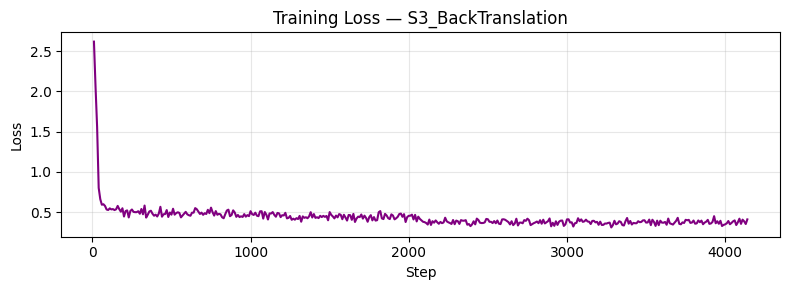

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

# Free translation models
for tok, mdl in marian_cache.values(): mdl.cpu()
torch.cuda.empty_cache()

print(f'Loading {MODEL_ID}...')
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID, load_in_4bit=True, use_gradient_checkpointing='unsloth')
model = FastVisionModel.get_peft_model(
    model, finetune_vision_layers=False, finetune_language_layers=True,
    finetune_attention_modules=True, finetune_mlp_modules=True,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias='none', random_state=RANDOM_SEED,
)
hf_train = Dataset.from_list([{'messages': c['messages']} for c in all_train_convs])
trainer = SFTTrainer(
    model=model, tokenizer=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    train_dataset=hf_train,
    args=SFTConfig(
        output_dir=str(CKPT_DIR), num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        warmup_steps=WARMUP_STEPS, learning_rate=LR, lr_scheduler_type='cosine',
        fp16=not is_bf16_supported(), bf16=is_bf16_supported(),
        logging_steps=LOG_STEPS, save_steps=SAVE_STEPS, save_total_limit=2,
        optim='adamw_8bit', weight_decay=0.01, seed=RANDOM_SEED,
        report_to='none', remove_unused_columns=False,
        dataset_text_field='', dataset_kwargs={'skip_prepare_dataset': True},
        max_seq_length=MAX_SEQ_LEN,
    ),
)
print(f'Training {STRATEGY}...')
import glob as _glob; _ckpts = sorted(
    _glob.glob(str(CKPT_DIR / 'checkpoint-*')),
    key=lambda x: int(x.split("checkpoint-")[-1])
)
_resume = _ckpts[-1] if _ckpts else False
if _resume: print(f'Resuming from checkpoint: {_resume}')
train_result = trainer.train(resume_from_checkpoint=_resume)
print(f'Loss: {train_result.training_loss:.4f}  Runtime: {train_result.metrics.get("train_runtime",0)/60:.1f} min')
adapter_dir = CKPT_DIR / 'final_adapter'
model.save_pretrained(adapter_dir); processor.save_pretrained(adapter_dir)

logs = [e for e in trainer.state.log_history if 'loss' in e]
if logs:
    plt.figure(figsize=(8,3))
    plt.plot([e['step'] for e in logs], [e['loss'] for e in logs], color='purple')
    plt.title(f'Training Loss — {STRATEGY}'); plt.xlabel('Step'); plt.ylabel('Loss')
    plt.grid(True,alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'training_loss.png',dpi=150); plt.show()

Evaluating EN (200 samples)...


EN:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating FR (200 samples)...


FR:   0%|          | 0/200 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating ZH (200 samples)...


ZH:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

RESULTS — S3_BackTranslation
[EN]  IoU=0.2020  Spearman=0.2377  CatF1=0.2593
[FR]  IoU=0.2939  Spearman=0.3043  CatF1=0.2688
[IT]  IoU=0.3123  Spearman=0.3617  CatF1=0.2903
[ZH]  IoU=0.2901  Spearman=0.3187  CatF1=0.2215
[OVERALL]  IoU=0.2746  Spearman=0.3056  CatF1=0.2564


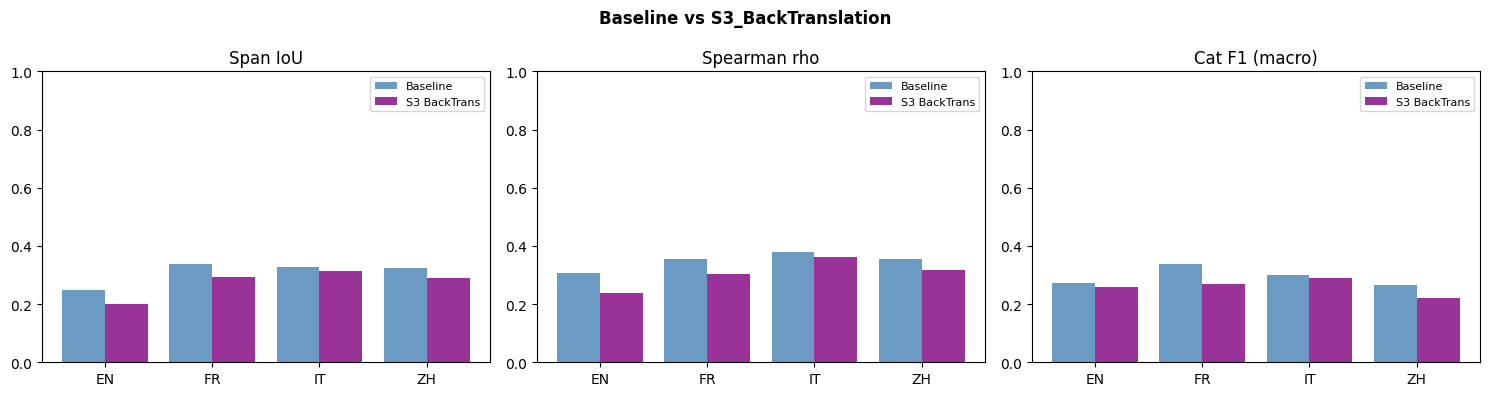

In [ ]:
FastVisionModel.for_inference(model)
device = next(model.parameters()).device

def run_inference(conv):
    msgs = conv['messages']
    text_input = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(msgs)
    inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=False, pad_token_id=processor.tokenizer.pad_token_id)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

LABEL_NORM = {'mischaracterisation':'mischaracterization','ocr_problem':'OCR','ocr problem':'OCR','ocr':'OCR','fabrication':'invention'}

def parse_model_output(raw):
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m: return []
    try: spans = json.loads(m.group())
    except: return []
    out = []
    for sp in spans:
        if not isinstance(sp, dict) or 'text' not in sp: continue
        text  = str(sp['text']).strip()
        if not text: continue
        label = LABEL_NORM.get(str(sp.get('label','other')).lower().strip(), str(sp.get('label','other')).lower().strip())
        if label not in VALID_LABELS: label = 'other'
        prob = max(0.0, min(1.0, float(sp.get('prob', 0.8))))
        out.append({'text': text, 'prob': prob, 'label': label})
    return out

def find_span_pos(response, text):
    if not text: return None
    pos = response.find(text)
    if pos != -1: return pos, pos + len(text)
    pos = response.lower().find(text.lower())
    if pos != -1: return pos, pos + len(text)
    if len(text) >= 8:
        tl, rl, tlen = text.lower(), response.lower(), len(text)
        step = max(1, tlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(response)-tlen+1), step):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(response)-tlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= 0.80: return best_pos, best_pos + tlen
    return None

def map_spans_to_positions(response, parsed):
    result, used = [], set()
    for sp in parsed:
        pos = find_span_pos(response, sp['text'])
        if pos is None: continue
        start, end = pos
        if len(set(range(start, end)) & used) > (end-start)*0.5: continue
        result.append({'start': start, 'end': end, 'prob': sp['prob'], 'label': sp['label']})
        used.update(range(start, end))
    return sorted(result, key=lambda x: x['start'])

def predict_one(conv):
    return map_spans_to_positions(conv['_response'], parse_model_output(run_inference(conv)))

def span_iou(pred, gold):
    p = set(i for s in pred for i in range(s['start'], s['end']))
    g = set(i for s in gold for i in range(s['start'], s['end']))
    if not p and not g: return 1.0
    return len(p & g) / len(p | g)

def spearman_rho(pred, gold, resp_len):
    pa = np.zeros(resp_len); ga = np.zeros(resp_len)
    for s in pred:
        for i in range(s['start'], min(s['end'], resp_len)): pa[i] = max(pa[i], s['prob'])
    for s in gold:
        for i in range(s['start'], min(s['end'], resp_len)): ga[i] = max(ga[i], s['prob'])
    if np.allclose(pa, pa[0]) and np.allclose(ga, ga[0]):
        return 1.0 if np.allclose(pa, ga) else 0.0
    rho, _ = spearmanr(pa, ga)
    return float(rho) if not np.isnan(rho) else 0.0

def category_f1(pred, gold, min_iou=0.3):
    tp, fp, fn = Counter(), Counter(), Counter()
    used_gold, used_pred = set(), set()
    for pi, p in enumerate(pred):
        pc = set(range(p['start'], p['end']))
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gold):
            if gi in used_gold: continue
            gc = set(range(g['start'], g['end']))
            iou = len(pc & gc) / max(len(pc | gc), 1)
            if iou > best_iou: best_iou, best_gi = iou, gi
        if best_iou >= min_iou and best_gi != -1:
            if p['label'] == gold[best_gi]['label']: tp[gold[best_gi]['label']] += 1
            else: fp[p['label']] += 1; fn[gold[best_gi]['label']] += 1
            used_gold.add(best_gi); used_pred.add(pi)
    for pi, p in enumerate(pred):
        if pi not in used_pred: fp[p['label']] += 1
    for gi, g in enumerate(gold):
        if gi not in used_gold: fn[g['label']] += 1
    scores = {}
    for cat in LABEL_ORDER:
        prec = tp[cat] / max(tp[cat]+fp[cat], 1)
        rec  = tp[cat] / max(tp[cat]+fn[cat], 1)
        scores[cat] = 2*prec*rec / max(prec+rec, 1e-9)
    scores['macro'] = float(np.mean(list(scores.values())))
    return scores

def evaluate_predictions(convs, predictions):
    ious, rhos, all_pred, all_gold = [], [], [], []
    for conv in convs:
        gold = conv['_labels']; pred = predictions.get(conv['_id'], [])
        ious.append(span_iou(pred, gold))
        rhos.append(spearman_rho(pred, gold, len(conv['_response'])))
        all_pred.extend(pred); all_gold.extend(gold)
    return {'mean_iou': float(np.mean(ious)), 'mean_spearman': float(np.nanmean(rhos)),
            'cat_f1': category_f1(all_pred, all_gold), 'n': len(convs)}

val_by_lang = defaultdict(list)
for conv in all_val_convs: val_by_lang[conv['_lang']].append(conv)
val_predictions = {}
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    print(f'Evaluating {lang.upper()} ({len(convs)} samples)...')
    for conv in tqdm(convs, desc=lang.upper()):
        try: val_predictions[conv['_id']] = predict_one(conv)
        except: val_predictions[conv['_id']] = []

results_by_lang = {}
print('=' * 60)
print(f'RESULTS — {STRATEGY}')
print('=' * 60)
for lang, convs in val_by_lang.items():
    m = evaluate_predictions(convs[:MAX_VAL_SAMPLES], val_predictions)
    results_by_lang[lang] = m
    print(f'[{lang.upper()}]  IoU={m["mean_iou"]:.4f}  Spearman={m["mean_spearman"]:.4f}  CatF1={m["cat_f1"]["macro"]:.4f}')

all_val_limited = [c for lc in val_by_lang.values() for c in lc[:MAX_VAL_SAMPLES]]
overall = evaluate_predictions(all_val_limited, val_predictions)
print(f'[OVERALL]  IoU={overall["mean_iou"]:.4f}  Spearman={overall["mean_spearman"]:.4f}  CatF1={overall["cat_f1"]["macro"]:.4f}')

rows = []
for lang in LANGUAGES:
    if lang not in results_by_lang: continue
    m = results_by_lang[lang]
    row = {'Language': lang.upper(), 'Span IoU': round(m['mean_iou'],4),
           'Spearman rho': round(m['mean_spearman'],4), 'Cat F1 (macro)': round(m['cat_f1']['macro'],4)}
    for cat in LABEL_ORDER: row[f'F1({cat[:4]})'] = round(m['cat_f1'].get(cat,0.0),4)
    rows.append(row)
row_all = {'Language':'OVERALL','Span IoU':round(overall['mean_iou'],4),
           'Spearman rho':round(overall['mean_spearman'],4),'Cat F1 (macro)':round(overall['cat_f1']['macro'],4)}
for cat in LABEL_ORDER: row_all[f'F1({cat[:4]})'] = round(overall['cat_f1'].get(cat,0.0),4)
rows.append(row_all)
results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR/f'{STRATEGY}_results.csv', index=False)

if BASELINE_CSV.exists():
    baseline_df = pd.read_csv(BASELINE_CSV)
    if 'Spearman \u03c1' in baseline_df.columns:
        baseline_df = baseline_df.rename(columns={'Spearman \u03c1': 'Spearman rho'})
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    langs_p = [l for l in LANGUAGES if l.upper() in results_df['Language'].values]
    for ax, met in zip(axes, ['Span IoU','Spearman rho','Cat F1 (macro)']):
        bv = [float(baseline_df[baseline_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        av = [float(results_df[results_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        x = np.arange(len(langs_p))
        ax.bar(x-0.2, bv, 0.4, label='Baseline', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, av, 0.4, label='S3 BackTrans', color='purple', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs_p])
        ax.set_title(met); ax.set_ylim(0,1); ax.legend(fontsize=8)
    plt.suptitle(f'Baseline vs {STRATEGY}', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'comparison_chart.png', dpi=150); plt.show()
else:
    print(f'Baseline CSV not found at {BASELINE_CSV}')